### Tool creation for RAG agents with langgraph

To create tools for RAG agents using LangGraph, essentially building LLM-invocable functions that your agent can call as part of its reasoning -> acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:
- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

### ✅ Tool Design Requirements
A LangGraph tool must:
- Have a name
- Have a description (used by the LLM to decide when use it)
- Have a callable func, accepting a single input (usually str) and returning str

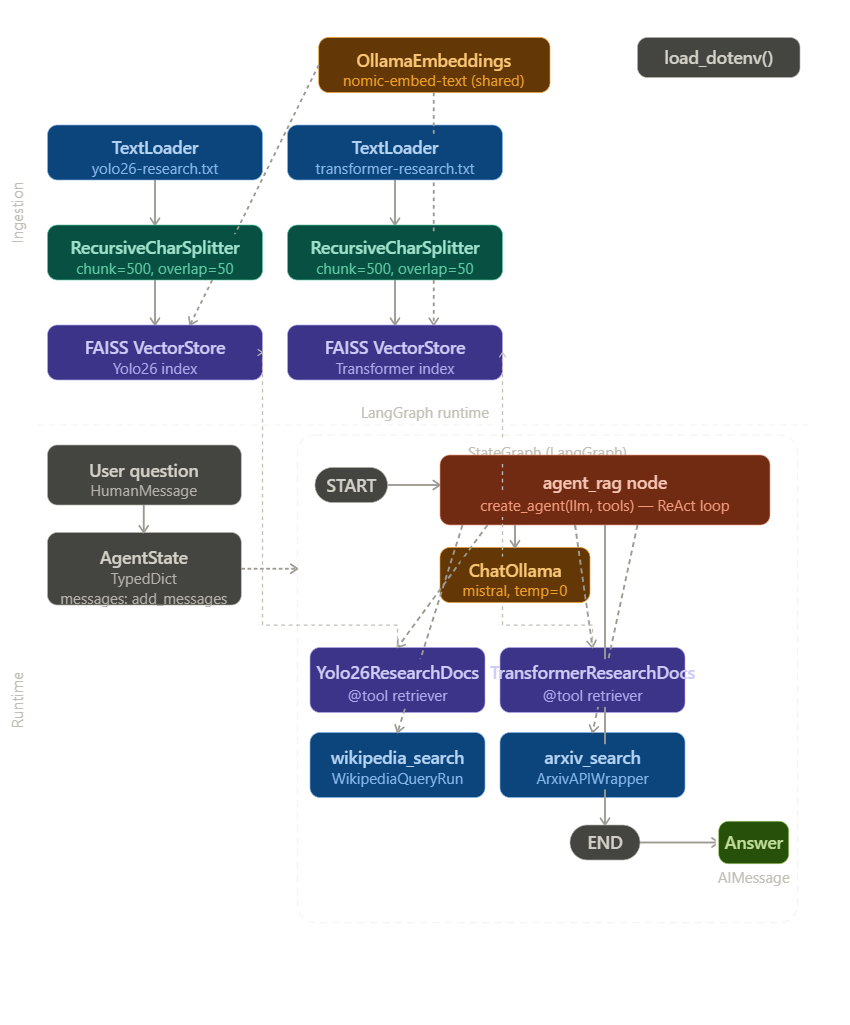

In [28]:
# ------------------------------------------------------------
# 1. Tools Function - Text Files, Wikipedia and Arxiv 
# ------------------------------------------------------------

from langchain_ollama import ChatOllama
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_community.document_loaders import TextLoader, WebBaseLoader, ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_classic.agents import Tool
from langchain_core.tools import tool
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun

import os
from dotenv import load_dotenv

load_dotenv()

# Embedding
embedding = OllamaEmbeddings(model='nomic-embed-text')

# LLM
llm = ChatOllama(model='mistral', temperature=0)

# Text Tool
def make_retriever_tool_from_text(file, name, desc):
    docs = TextLoader(file, encoding='utf-8').load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
    vector_store = FAISS.from_documents(chunks, embedding)
    retriever = vector_store.as_retriever()
    
    @tool(name)
    def retriever_tool(query: str) -> str:
        """Retriever tool"""
        print(f'📚 Using Tool: {name}')
        results = retriever.invoke(query)
        return '\n\n'.join(doc.page_content for doc in results)
    
    return retriever_tool

# Wikipedia Tool
wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

@tool
def wikipedia_search(query: str) -> str:
    """Fetch general world knowledge from Wikipedia."""
    return wiki.run(query)

# ArXiv Tool
arxiv = ArxivAPIWrapper()

@tool
def arxiv_search(query: str) -> str:
    """Fetch Arxiv summaries without PDF parsing."""
    try:
        print('🔎 Searching ArXiv...')
        return arxiv.run(query)
    
    except Exception as e:
        return f"Arxiv tool error: {str(e)}"

In [29]:
yolo26_tool = make_retriever_tool_from_text(
    file='data/yolo26-research.txt',
    name='Yolo26ResearchDocs',
    desc='Yolo26 research document for overview and key features'
)

transformer_tool = make_retriever_tool_from_text(
    file='data/transformer-research.txt',
    name='TransformerResearchDocs',
    desc='Transformer research document for experimental log and conclusion.'
)

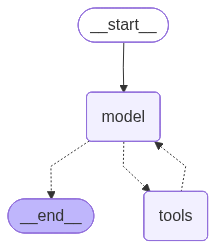

In [30]:
from langchain.agents import create_agent

tools = [yolo26_tool, transformer_tool, wikipedia_search, arxiv_search]

react_node = create_agent(llm, tools)
react_node

In [31]:
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END, add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

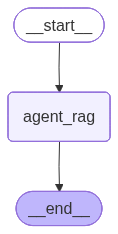

In [32]:
builder = StateGraph(AgentState)

builder.add_node('agent_rag', react_node)
builder.set_entry_point('agent_rag')
builder.add_edge('agent_rag', END)

graph = builder.compile()
graph

In [33]:
query = 'What is about transformer variants and what does ArXiv suggest recently?'

state = {'messages': [HumanMessage(content=query)]}
result = graph.invoke(state)

print('\n✅ Final Answer:\n', result['messages'][-1].content)

📚 Using Tool: TransformerResearchDocs
🔎 Searching ArXiv...

✅ Final Answer:
  The ArXiv suggests several recent research papers related to Transformer variants:

1. PyramidTNT: Improved Transformer-in-Transformer Baselines with Pyramid Architecture - This paper presents new baselines for vision transformers by introducing a pyramid architecture and convolutional stem, which significantly improves the original TNT and achieves better performances than previous state-of-the-art vision transformers.

2. Learning to Cluster Faces via Transformer - In this paper, the authors repurpose the Transformer for supervised face clustering. They decompose the face clustering into two steps: relation encoding and linkage predicting. Experiments on MS-Celeb-1M and DeepFashion show that their method achieves state-of-the-art performance.

3. MLP Can Be A Good Transformer Learner - This paper introduces a novel strategy to simplify vision transformers by selectively removing non-essential attention laye